<a href="https://colab.research.google.com/github/su690/-Currency_Converter/blob/main/Copy_of_Experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


✅ HTML report generated: 'glacier_polynomial_report.html'


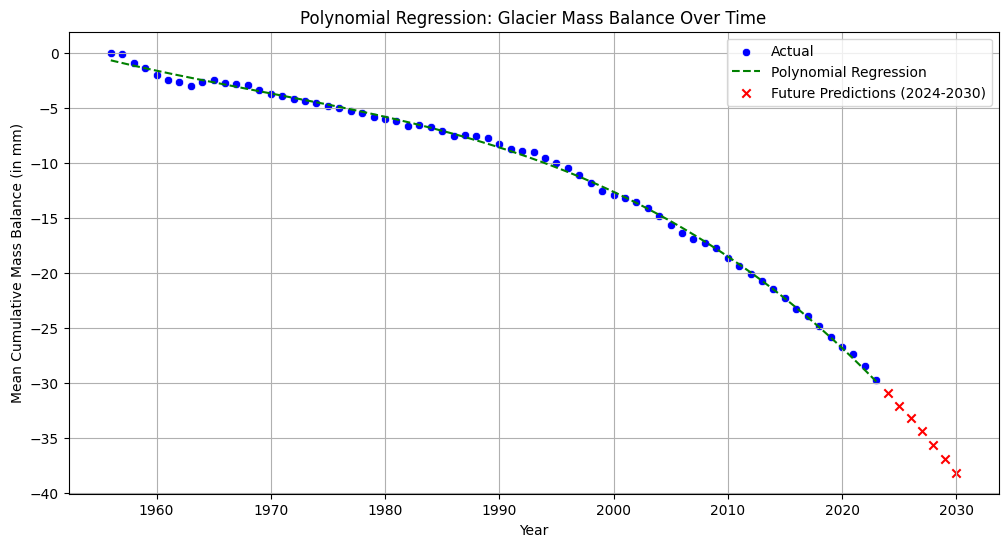

In [ ]:
# === Import Libraries ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from io import BytesIO
import base64

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

# === Features & Target ===
X = df[['Year']]
y = df['Mean cumulative mass balance']

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Polynomial Features (Degree 3) ===
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_train)

# === Train Model ===
model = LinearRegression()
model.fit(X_poly, y_train)

# === Predict and Evaluate ===
y_pred = model.predict(poly.transform(X_test))
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# === Polynomial Equation String ===
coeffs = model.coef_
intercept = model.intercept_
terms = [f"{intercept:.4f}"]
for power, coef in enumerate(coeffs[1:], 1):
    terms.append(f"{coef:.4f} * x^{power}")
equation = " + ".join(terms)

# === Prediction Line and Future Predictions ===
X_range = np.linspace(df['Year'].min(), df['Year'].max(), 300).reshape(-1, 1)
y_range = model.predict(poly.transform(X_range))

future_years = pd.DataFrame({'Year': list(range(2024, 2031))})
future_preds = model.predict(poly.transform(future_years))

# === Plotting ===
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Year', y='Mean cumulative mass balance', data=df, label='Actual', color='blue')
plt.plot(X_range, y_range, color='green', linestyle='--', label='Polynomial Regression')
plt.scatter(future_years, future_preds, color='red', marker='x', label='Future Predictions (2024-2030)')
plt.title('Polynomial Regression: Glacier Mass Balance Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)

# === Save plot as base64 for HTML embedding ===
buf = BytesIO()
plt.savefig(buf, format="png")
buf.seek(0)
encoded_image = base64.b64encode(buf.read()).decode("utf-8")
buf.close()

# === HTML Report Generation ===
html_content = f"""
<html>
<head>
    <title>Glacier Mass Balance Report</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            background-color: #f9f9f9;
            color: #333;
            padding: 20px;
            max-width: 1000px;
            margin: auto;
        }}
        h1, h2, h3 {{
            color: #004080;
        }}
        pre {{
            background: #f0f0f0;
            padding: 10px;
            border-radius: 6px;
            font-size: 1em;
        }}
        img {{
            max-width: 100%;
            border: 1px solid #ccc;
            border-radius: 6px;
            margin-top: 20px;
        }}
    </style>
</head>
<body>

<h1>Glacier Mass Balance Analysis Report</h1>

<h2>Polynomial Regression Equation</h2>
<pre>
y = {equation}
</pre>

<h2>Model Evaluation Metrics</h2>
<pre>
R² Score: {r2:.4f}
Mean Squared Error: {mse:.4f}
</pre>

<h2>Future Predictions (2024–2030)</h2>
<pre>
"""
for year, pred in zip(future_years['Year'], future_preds):
    html_content += f"Year {year}: {pred:.2f} mm\n"

html_content += f"""
</pre>

<h2>Visualization</h2>
<img src="data:image/png;base64,{encoded_image}" alt="Polynomial Regression Curve">

</body>
</html>
"""

# === Save HTML file ===
with open("glacier_polynomial_report.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("✅ HTML report generated: 'glacier_polynomial_report.html'")

# New section

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving glaciers.csv to glaciers (3).csv


✅ Linear Regression Equation: y = -0.3996 * x + 784.2959
✅ R² Score: 0.9293
✅ Mean Squared Error: 5.2796


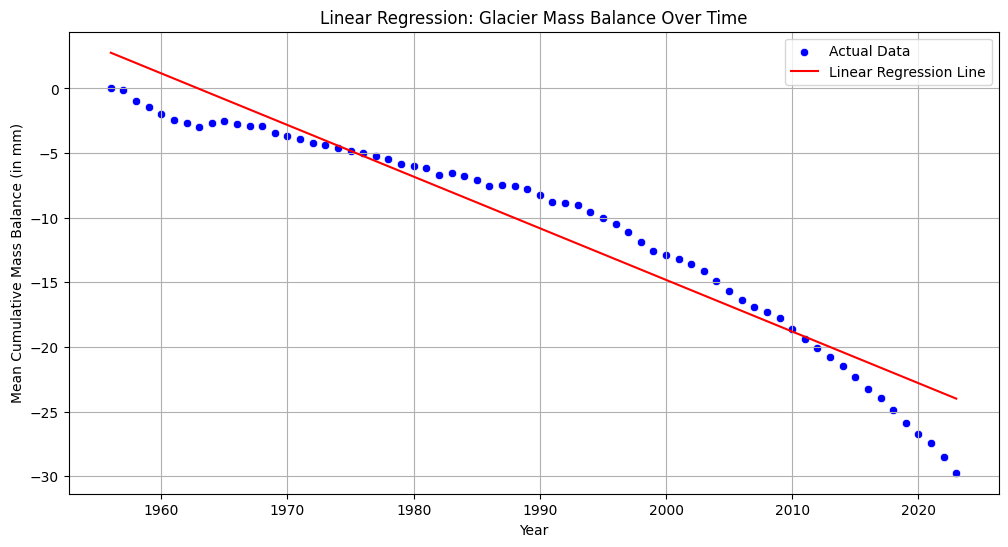

In [ ]:
# === Import Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

# === Features & Target ===
X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Train Linear Regression Model ===
model = LinearRegression()
model.fit(X_train, y_train)

# === Predict and Evaluate ===
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# === Line Equation ===
slope = model.coef_[0]
intercept = model.intercept_
equation = f"y = {slope:.4f} * x + {intercept:.4f}"

print("✅ Linear Regression Equation:", equation)
print(f"✅ R² Score: {r2:.4f}")
print(f"✅ Mean Squared Error: {mse:.4f}")

# === Plotting ===
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Year', y='Mean cumulative mass balance', data=df, label='Actual Data', color='blue')
plt.plot(X, model.predict(X), color='red', label='Linear Regression Line')
plt.title('Linear Regression: Glacier Mass Balance Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving glaciers.csv to glaciers (4).csv


✅ Ridge Regression Equation: y = -0.3995 * x + 784.2544
✅ R² Score: 0.9293
✅ Mean Squared Error: 5.2791


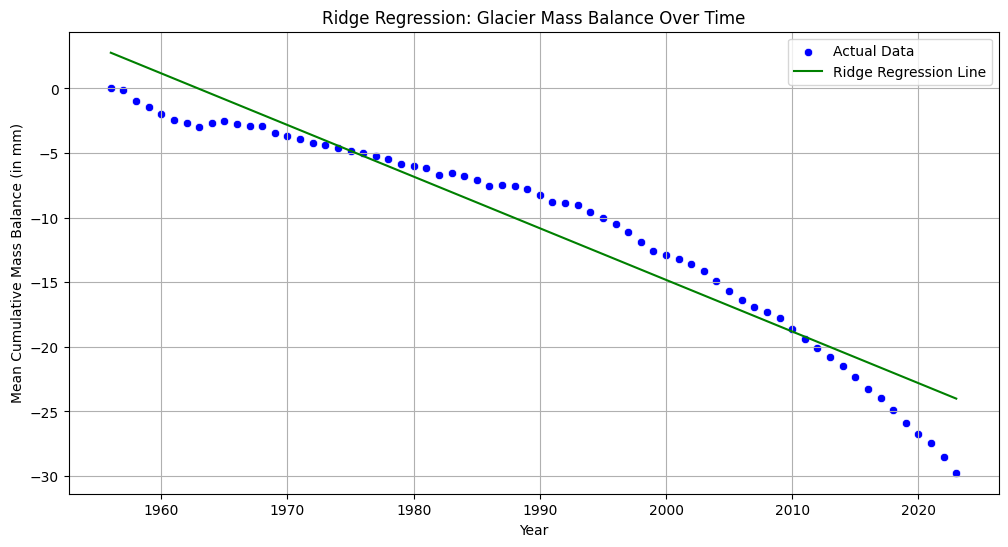

In [ ]:
# === Import Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

# === Features & Target ===
X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Train Ridge Regression Model ===
ridge_model = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge_model.fit(X_train, y_train)

# === Predict and Evaluate ===
y_pred = ridge_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# === Line Equation ===
slope = ridge_model.coef_[0]
intercept = ridge_model.intercept_
equation = f"y = {slope:.4f} * x + {intercept:.4f}"

print("✅ Ridge Regression Equation:", equation)
print(f"✅ R² Score: {r2:.4f}")
print(f"✅ Mean Squared Error: {mse:.4f}")

# === Plotting ===
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Year', y='Mean cumulative mass balance', data=df, label='Actual Data', color='blue')
plt.plot(X, ridge_model.predict(X), color='green', label='Ridge Regression Line')
plt.title('Ridge Regression: Glacier Mass Balance Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glaciers.csv to glaciers (5).csv


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


R² Score: 1.0000
Mean Squared Error: 0.0000


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glaciers.csv to glaciers (6).csv



🔵 Model Performance on Glacier Dataset:

                                  R2 Score       MSE
Random Forest Regressor           0.998772  0.091748
Polynomial Regression (Degree 3)  0.998709  0.096412
MLP Regressor                     0.997980  0.150877
Gradient Boosting Regressor       0.997038  0.221215
Decision Tree Regressor           0.997036  0.221355
XGBoost Regressor                 0.995734  0.318651
Lasso Regression                  0.929323  5.278858
Ridge Regression                  0.929321  5.279056
Linear Regression                 0.929313  5.279617


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


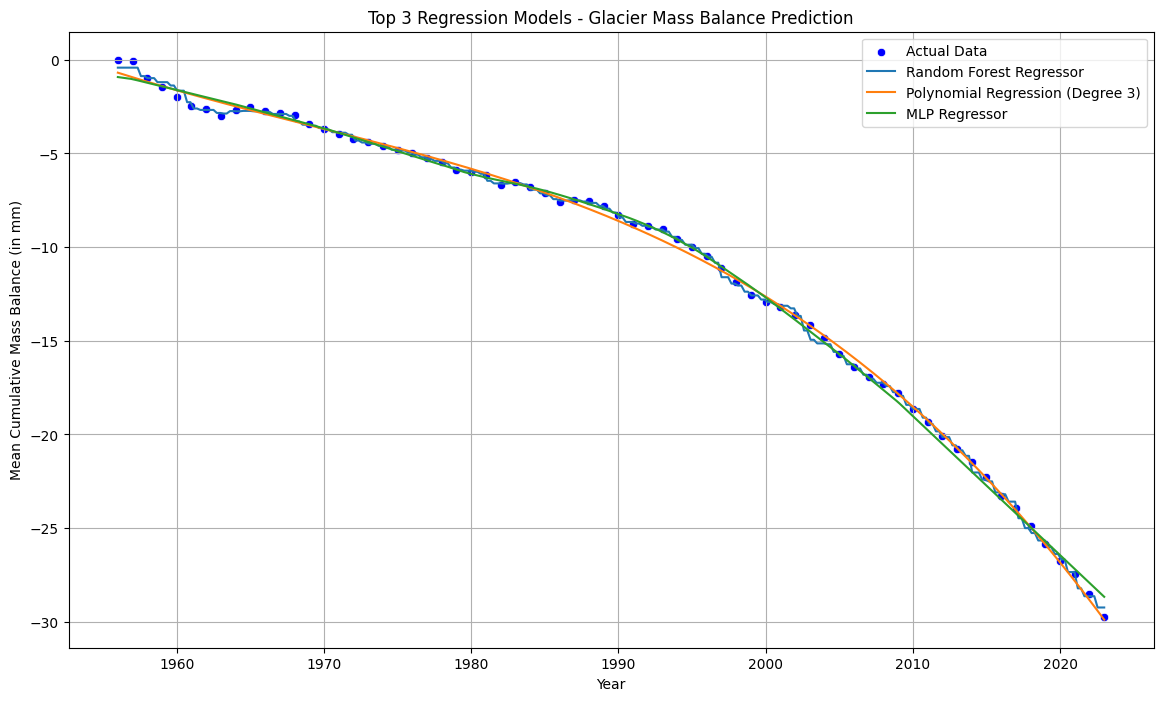

In [ ]:
# === Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Models Dictionary ===
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Polynomial Regression (Degree 3)": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# === Result Storage ===
results = {}

# === Preprocessing for MLP ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Training & Evaluation Loop ===
for name, model in models.items():
    if "Polynomial" in name:
        # Special handling for Polynomial Regression
        poly = PolynomialFeatures(degree=3)
        X_poly_train = poly.fit_transform(X_train)
        X_poly_test = poly.transform(X_test)
        model.fit(X_poly_train, y_train)
        y_pred = model.predict(X_poly_test)
    elif "MLP" in name:
        # Special handling for Neural Network (needs scaled input)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # All other models
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {"R2 Score": r2, "MSE": mse}

# === Display Results ===
results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
print("\n🔵 Model Performance on Glacier Dataset:\n")
print(results_df)

# === Plot Top 3 Models ===
top3_models = results_df.head(3).index.tolist()

plt.figure(figsize=(14, 8))
sns.scatterplot(x=df['Year'], y=df['Mean cumulative mass balance'], label='Actual Data', color='blue')

for model_name in top3_models:
    model = models[model_name]

    if "Polynomial" in model_name:
        X_range = np.linspace(X['Year'].min(), X['Year'].max(), 300).reshape(-1, 1)
        X_poly_range = PolynomialFeatures(degree=3).fit_transform(X_range)
        y_range_pred = model.predict(X_poly_range)
    elif "MLP" in model_name:
        X_range = np.linspace(X['Year'].min(), X['Year'].max(), 300).reshape(-1, 1)
        X_range_scaled = scaler.transform(X_range)
        y_range_pred = model.predict(X_range_scaled)
    else:
        X_range = np.linspace(X['Year'].min(), X['Year'].max(), 300).reshape(-1, 1)
        y_range_pred = model.predict(X_range)

    plt.plot(X_range, y_range_pred, label=f"{model_name}")

plt.title('Top 3 Regression Models - Glacier Mass Balance Prediction')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glaciers.csv to glaciers (7).csv



🔵 Model Performance on Glacier Dataset:

                                  R2 Score       MSE
Random Forest Regressor           0.998772  0.091748
Polynomial Regression (Degree 3)  0.998709  0.096412
MLP Regressor                     0.997980  0.150877
Gradient Boosting Regressor       0.997038  0.221215
Decision Tree Regressor           0.997036  0.221355
XGBoost Regressor                 0.995734  0.318651
Lasso Regression                  0.929323  5.278858
Ridge Regression                  0.929321  5.279056
Linear Regression                 0.929313  5.279617


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


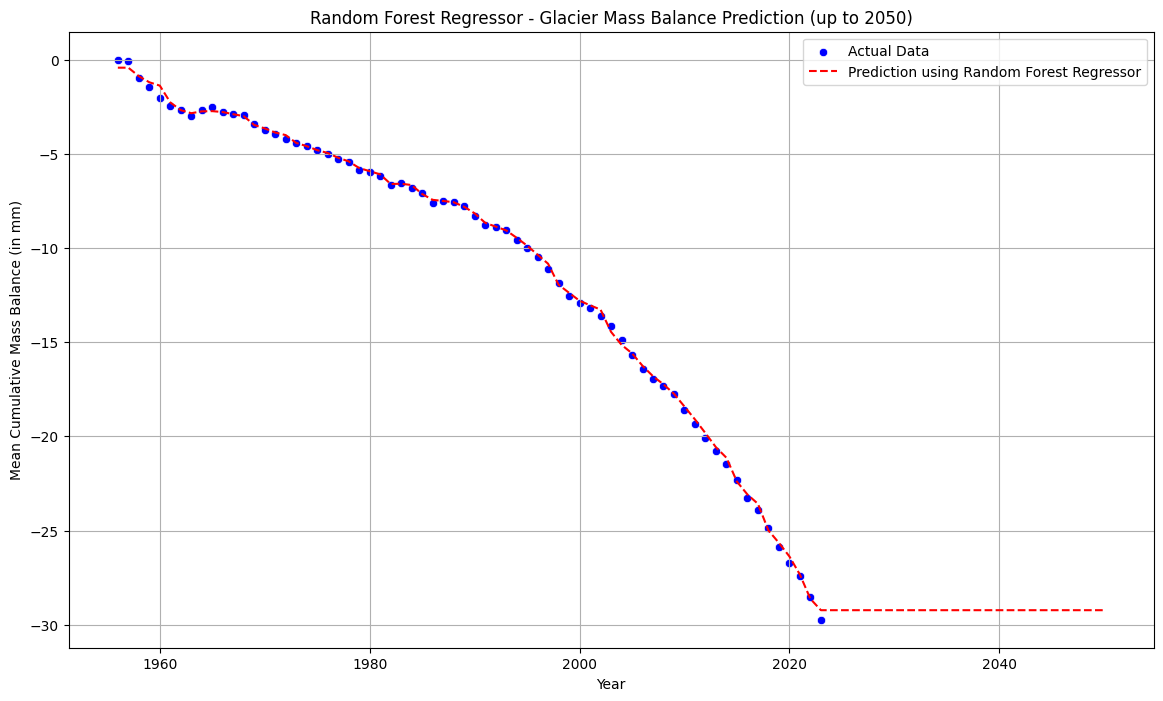


📅 Future Predictions (Year vs Predicted Mass Balance):
    Year  Predicted Mass Balance
0   1956                -0.42295
1   1957                -0.42295
2   1958                -0.87483
3   1959                -1.19707
4   1960                -1.37585
..   ...                     ...
90  2046               -29.23183
91  2047               -29.23183
92  2048               -29.23183
93  2049               -29.23183
94  2050               -29.23183

[95 rows x 2 columns]


In [ ]:
# === Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Models Dictionary ===
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Polynomial Regression (Degree 3)": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# === Result Storage ===
results = {}

# === Preprocessing for MLP ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Training & Evaluation Loop ===
for name, model in models.items():
    if "Polynomial" in name:
        # Special handling for Polynomial Regression
        poly = PolynomialFeatures(degree=3)
        X_poly_train = poly.fit_transform(X_train)
        X_poly_test = poly.transform(X_test)
        model.fit(X_poly_train, y_train)
        y_pred = model.predict(X_poly_test)
    elif "MLP" in name:
        # Special handling for Neural Network (needs scaled input)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # All other models
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {"R2 Score": r2, "MSE": mse}

# === Display Results ===
results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
print("\n🔵 Model Performance on Glacier Dataset:\n")
print(results_df)

# === Use the Best Model for Future Prediction ===
best_model_name = results_df.head(1).index[0]  # Best model based on R² Score
best_model = models[best_model_name]

# Extend the Year range to 2050
future_years = np.arange(X['Year'].min(), 2051).reshape(-1, 1)

# Predict for future years
if "Polynomial" in best_model_name:
    poly = PolynomialFeatures(degree=3)
    future_years_poly = poly.fit_transform(future_years)
    future_predictions = best_model.predict(future_years_poly)
elif "MLP" in best_model_name:
    future_years_scaled = scaler.transform(future_years)
    future_predictions = best_model.predict(future_years_scaled)
else:
    future_predictions = best_model.predict(future_years)

# === Plot Actual vs Predicted (including future years) ===
plt.figure(figsize=(14, 8))
sns.scatterplot(x=df['Year'], y=df['Mean cumulative mass balance'], label='Actual Data', color='blue')

plt.plot(future_years, future_predictions, label=f"Prediction using {best_model_name}", color='red', linestyle='--')

plt.title(f'{best_model_name} - Glacier Mass Balance Prediction (up to 2050)')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()

# === Display Future Predictions ===
future_df = pd.DataFrame({'Year': future_years.flatten(), 'Predicted Mass Balance': future_predictions})
print("\n📅 Future Predictions (Year vs Predicted Mass Balance):")
print(future_df)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glaciers.csv to glaciers (8).csv


Linear Regression Model Performance:
R² Score: 0.9293133088567139
Mean Squared Error: 5.279616889947964


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


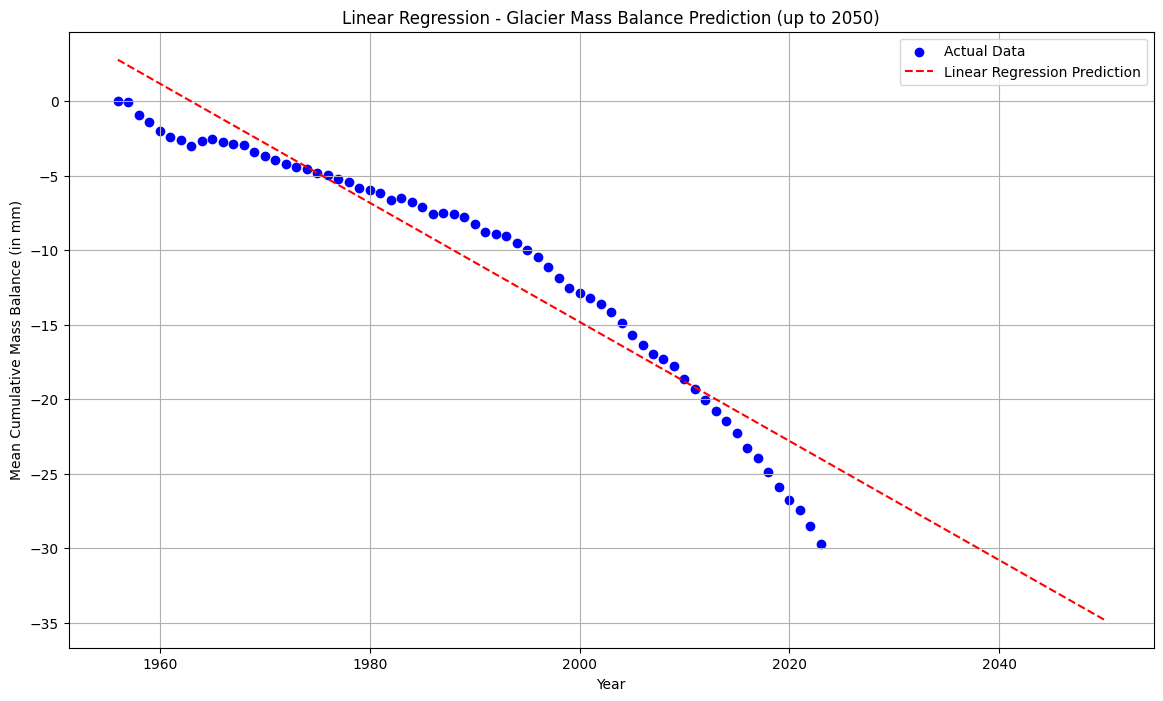


📅 Future Predictions (Year vs Predicted Mass Balance):
    Year  Predicted Mass Balance
0   1956                2.766331
1   1957                2.366776
2   1958                1.967221
3   1959                1.567666
4   1960                1.168111
..   ...                     ...
90  2046              -33.193620
91  2047              -33.593175
92  2048              -33.992730
93  2049              -34.392285
94  2050              -34.791841

[95 rows x 2 columns]


In [ ]:
# === Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Train Linear Regression Model ===
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# === Predict and Evaluate ===
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")

# === Extend Year Range to 2050 ===
future_years = np.arange(X['Year'].min(), 2051).reshape(-1, 1)

# Predict for future years (up to 2050)
future_predictions = linear_model.predict(future_years)

# === Plot Actual vs Predicted (including future years) ===
plt.figure(figsize=(14, 8))
plt.scatter(df['Year'], df['Mean cumulative mass balance'], label='Actual Data', color='blue')
plt.plot(future_years, future_predictions, label="Linear Regression Prediction", color='red', linestyle='--')

plt.title('Linear Regression - Glacier Mass Balance Prediction (up to 2050)')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()

# === Display Future Predictions ===
future_df = pd.DataFrame({'Year': future_years.flatten(), 'Predicted Mass Balance': future_predictions})
print("\n📅 Future Predictions (Year vs Predicted Mass Balance):")
print(future_df)


Linear Regression Model Performance:
R² Score: 0.9293133088567139
Mean Squared Error: 5.279616889947964


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


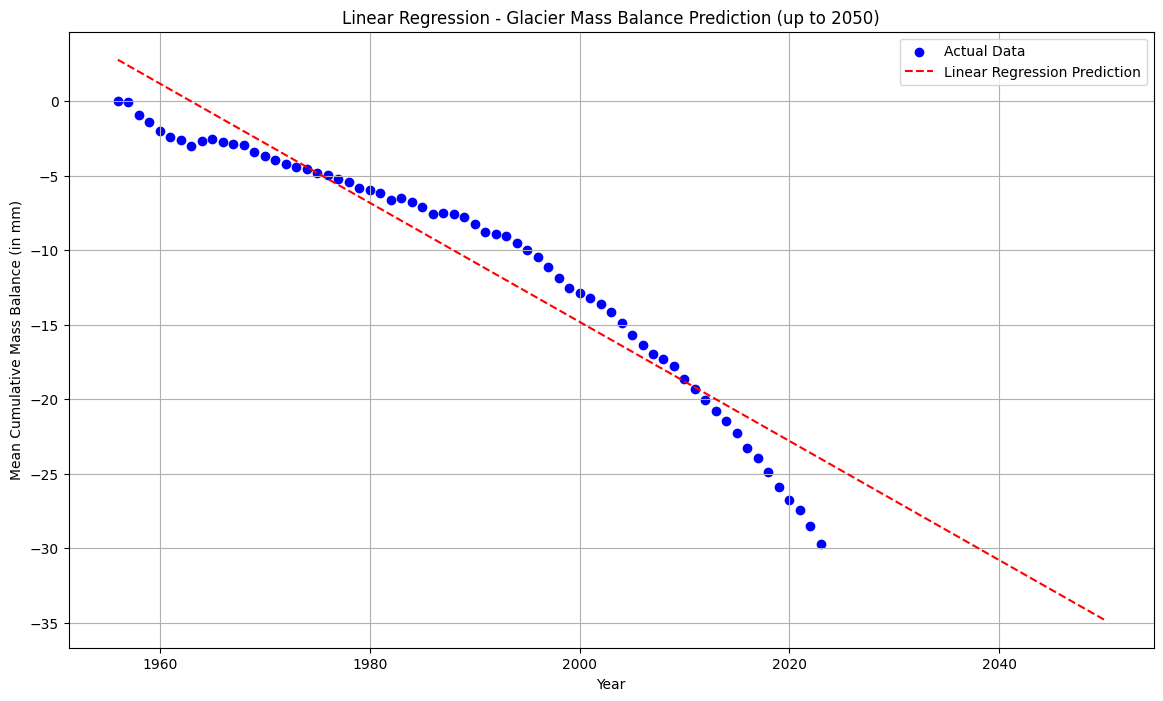


✅ CSV file 'glacier_predictions_2050.csv' created successfully.


In [ ]:
# === Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# === Load Dataset ===
df = pd.read_csv("glaciers.csv")
df.dropna(subset=['Mean cumulative mass balance'], inplace=True)

X = df[['Year']]  # Feature
y = df['Mean cumulative mass balance']  # Target

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Train Linear Regression Model ===
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# === Predict and Evaluate ===
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")

# === Extend Year Range to 2050 ===
future_years = np.arange(X['Year'].min(), 2051).reshape(-1, 1)

# Predict for future years (up to 2050)
future_predictions = linear_model.predict(future_years)

# === Plot Actual vs Predicted (including future years) ===
plt.figure(figsize=(14, 8))
plt.scatter(df['Year'], df['Mean cumulative mass balance'], label='Actual Data', color='blue')
plt.plot(future_years, future_predictions, label="Linear Regression Prediction", color='red', linestyle='--')

plt.title('Linear Regression - Glacier Mass Balance Prediction (up to 2050)')
plt.xlabel('Year')
plt.ylabel('Mean Cumulative Mass Balance (in mm)')
plt.legend()
plt.grid(True)
plt.show()

# === Create DataFrame for Future Predictions ===
future_df = pd.DataFrame({'Year': future_years.flatten(), 'Predicted Mass Balance': future_predictions})

# === Save Future Predictions to CSV ===
future_df.to_csv("glacier_predictions_2050.csv", index=False)

print("\n✅ CSV file 'glacier_predictions_2050.csv' created successfully.")
